# IBM hardware ordering-probe sanity check

**Channel-Level Diagnostic for Symmetry Breaking in Noisy Equivariant Quantum Neural Networks
by H. Ugail and N. Howard**

This compares two orderings of a symmetry-like rotation \(G\) and a non-commuting perturbation \(E\):

- \(G\) then \(E\): \(R_z(\pi/2)\) followed by \(R_x(\pi/2)\)
- \(E\) then \(G\): \(R_x(\pi/2)\) followed by \(R_z(\pi/2)\)

The output states are measured in the \(X\), \(Y\), and \(Z\) bases, converted into empirical Bloch vectors, and compared with the ideal noiseless prediction.

**Important scope note.** This is **not** a hardware estimate of the channel-level compliance score \(C_G\). A hardware-grounded estimate of \(C_G\) would require process tomography, gate-set tomography, randomized compiling, or another finite-shot channel-estimation protocol. This notebook is a hardware execution sanity check showing that representative ordering probes can be submitted to a real backend and analysed reproducibly.

## 0. Optional installation

Uncomment and run the following cell if the notebook environment does not already have Qiskit and Qiskit Runtime installed.

In [ ]:
!pip install -U qiskit qiskit-ibm-runtime qiskit-aer matplotlib pandas

## 1. Imports and configuration

In [ ]:
import json
import math
import time
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector

from google.colab import drive
drive.mount('/content/drive')


# Runtime imports are only needed for the hardware section.
try:
    from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
    HAS_RUNTIME = True
except Exception as exc:
    HAS_RUNTIME = False
    print("qiskit-ibm-runtime is not available:", repr(exc))

# Optional Aer import for local sampled simulation, if installed.
try:
    from qiskit_aer import AerSimulator
    HAS_AER = True
except Exception as exc:
    HAS_AER = False
    print("qiskit-aer is not available; simulator section will be skipped:", repr(exc))

In [ ]:
# ----------------------------
# User configuration
# ----------------------------

# Use 4000 or more for a cleaner hardware demonstration.
SHOTS = 4000

# Set to True when ready to submit to IBM hardware.
RUN_HARDWARE = True

# If you want a specific backend, set its name here.
# Example: BACKEND_NAME = "ibm_kingston"
# If None, the notebook tries to choose a least-busy operational non-simulator backend.
BACKEND_NAME = "ibm_kingston"

# Optimization level for hardware transpilation.
OPTIMIZATION_LEVEL = 1

# Output directory for auditable JSON/CSV artifacts.
OUTPUT_DIR = Path("/content/drive/...")
OUTPUT_DIR.mkdir(exist_ok=True)

# Random seed used only for bootstrap confidence intervals.
BOOTSTRAP_SEED = 12345
BOOTSTRAP_REPS = 5000

print("SHOTS:", SHOTS)
print("RUN_HARDWARE:", RUN_HARDWARE)
print("BACKEND_NAME:", BACKEND_NAME)
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())

## 2. Circuit definitions

We choose \(G = R_z(\pi/2)\) and \(E = R_x(\pi/2)\), starting from \(|0\rangle\). These two orderings have a large ideal Bloch-vector separation:

- \(G\) then \(E\) ideally gives a Bloch vector close to \((0,-1,0)\).
- \(E\) then \(G\) ideally gives a Bloch vector close to \((1,0,0)\).

The ideal Bloch distance is \(1/\sqrt{2} \approx 0.7071\), which is much easier to detect than the earlier Z-basis-only probe.

In [ ]:
def base_ordering_circuit(order: str) -> QuantumCircuit:
    # Return a one-qubit circuit with no measurement.
    # order "GE": apply G then E: Rz(pi/2), then Rx(pi/2).
    # order "EG": apply E then G: Rx(pi/2), then Rz(pi/2).
    qc = QuantumCircuit(1, name=order)
    if order == "GE":
        qc.rz(np.pi / 2, 0)
        qc.rx(np.pi / 2, 0)
    elif order == "EG":
        qc.rx(np.pi / 2, 0)
        qc.rz(np.pi / 2, 0)
    else:
        raise ValueError("order must be 'GE' or 'EG'")
    return qc


def measurement_circuit(order: str, basis: str) -> QuantumCircuit:
    # Return a circuit measuring the chosen ordering in X, Y, or Z basis.
    qc = base_ordering_circuit(order)
    qc.name = f"{order}_{basis}"

    # Convert basis measurement to computational-basis measurement.
    if basis == "X":
        qc.h(0)
    elif basis == "Y":
        qc.sdg(0)
        qc.h(0)
    elif basis == "Z":
        pass
    else:
        raise ValueError("basis must be X, Y, or Z")

    qc.measure_all()
    return qc


orders = ["GE", "EG"]
bases = ["X", "Y", "Z"]

base_circuits = {order: base_ordering_circuit(order) for order in orders}
measure_circuits = {(order, basis): measurement_circuit(order, basis)
                    for order in orders for basis in bases}

print("Base circuit: G then E")
print(base_circuits["GE"])
print("\nBase circuit: E then G")
print(base_circuits["EG"])
print("\nMeasurement circuits:")
for key, circ in measure_circuits.items():
    print(key, circ.name, "depth:", circ.depth())

Base circuit: G then E
   ┌─────────┐┌─────────┐
q: ┤ Rz(π/2) ├┤ Rx(π/2) ├
   └─────────┘└─────────┘

Base circuit: E then G
   ┌─────────┐┌─────────┐
q: ┤ Rx(π/2) ├┤ Rz(π/2) ├
   └─────────┘└─────────┘

Measurement circuits:
('GE', 'X') GE_X depth: 4
('GE', 'Y') GE_Y depth: 5
('GE', 'Z') GE_Z depth: 3
('EG', 'X') EG_X depth: 4
('EG', 'Y') EG_Y depth: 5
('EG', 'Z') EG_Z depth: 3


## 3. Ideal noiseless prediction

In [ ]:
PAULI_X = np.array([[0, 1], [1, 0]], dtype=complex)
PAULI_Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
PAULI_Z = np.array([[1, 0], [0, -1]], dtype=complex)

def ideal_state(order: str) -> Statevector:
    return Statevector.from_instruction(base_circuits[order])

def bloch_from_statevector(sv: Statevector) -> np.ndarray:
    psi = np.asarray(sv.data)
    return np.array([
        np.vdot(psi, PAULI_X @ psi).real,
        np.vdot(psi, PAULI_Y @ psi).real,
        np.vdot(psi, PAULI_Z @ psi).real,
    ])

ideal_bloch = {order: bloch_from_statevector(ideal_state(order)) for order in orders}

ideal_distance = 0.5 * np.linalg.norm(ideal_bloch["GE"] - ideal_bloch["EG"])

ideal_df = pd.DataFrame(
    [
        {"ordering": order, "rx": vec[0], "ry": vec[1], "rz": vec[2]}
        for order, vec in ideal_bloch.items()
    ]
)
display(ideal_df)
print(f"Ideal Bloch distance 0.5*||r_GE - r_EG||_2 = {ideal_distance:.6f}")

,ordering,rx,ry,rz
0,GE,0.0,-1.000000e+00,2.220446e-16
1,EG,1.0,-2.220446e-16,2.220446e-16


Ideal Bloch distance 0.5*||r_GE - r_EG||_2 = 0.707107


## 4. Helper functions for counts, expectations, confidence intervals, and plots

In [ ]:
def normalize_counts(counts):
    # Return counts with string keys '0' and '1'.
    out = {"0": 0, "1": 0}
    for k, v in dict(counts).items():
        key = str(k)
        # Qiskit can return keys like '0', '1', or occasionally with spaces/register formatting.
        if key.endswith("0"):
            out["0"] += int(v)
        elif key.endswith("1"):
            out["1"] += int(v)
        else:
            out[key] = int(v)
    return out

def extract_counts_from_sampler_result(result, index: int, classical_register: str = "meas"):
    # Robustly extract counts from a SamplerV2 result.
    pub_result = result[index]
    data = pub_result.data

    # Try the requested register first, then common alternatives.
    candidate_registers = [classical_register, "c", "meas"]
    for reg in candidate_registers:
        try:
            bit_array = getattr(data, reg)
            return normalize_counts(bit_array.get_counts())
        except Exception:
            pass

    # Last-resort introspection over public-looking attributes.
    for reg in dir(data):
        if reg.startswith("_"):
            continue
        try:
            obj = getattr(data, reg)
            if hasattr(obj, "get_counts"):
                return normalize_counts(obj.get_counts())
        except Exception:
            continue

    raise RuntimeError(f"Could not extract counts from result index {index}. Data object: {data!r}")

def expval_from_counts(counts):
    # Return expectation of Pauli basis measurement: +1 for 0, -1 for 1.
    counts = normalize_counts(counts)
    n0 = counts.get("0", 0)
    n1 = counts.get("1", 0)
    n = n0 + n1
    if n == 0:
        return np.nan, np.nan, 0
    p0 = n0 / n
    expval = 2 * p0 - 1
    # Binomial standard error for expval = 2*p0 - 1
    se = 2 * math.sqrt(max(p0 * (1 - p0), 0) / n)
    return expval, se, n

def bloch_from_counts_by_basis(counts_by_basis):
    # counts_by_basis maps basis -> counts.
    vals = {}
    ses = {}
    shots = {}
    for basis in ["X", "Y", "Z"]:
        expv, se, n = expval_from_counts(counts_by_basis[basis])
        vals[basis] = expv
        ses[basis] = se
        shots[basis] = n
    return np.array([vals["X"], vals["Y"], vals["Z"]]), vals, ses, shots

def bootstrap_bloch_distance(counts_by_order_basis, reps=5000, seed=12345):
    # Bootstrap/binomial uncertainty for 0.5*||r_GE-r_EG||.
    rng = np.random.default_rng(seed)

    def sample_exp(counts):
        counts = normalize_counts(counts)
        n0 = counts.get("0", 0)
        n1 = counts.get("1", 0)
        n = n0 + n1
        p0 = n0 / n
        sampled_n0 = rng.binomial(n, p0, size=reps)
        return 2 * sampled_n0 / n - 1

    vectors = {}
    for order in ["GE", "EG"]:
        components = []
        for basis in ["X", "Y", "Z"]:
            components.append(sample_exp(counts_by_order_basis[(order, basis)]))
        vectors[order] = np.vstack(components).T

    dists = 0.5 * np.linalg.norm(vectors["GE"] - vectors["EG"], axis=1)
    return {
        "mean": float(np.mean(dists)),
        "std": float(np.std(dists, ddof=1)),
        "q025": float(np.quantile(dists, 0.025)),
        "q500": float(np.quantile(dists, 0.500)),
        "q975": float(np.quantile(dists, 0.975)),
    }

def summarize_counts(counts_by_order_basis, label):
    rows = []
    bloch = {}
    component_details = {}
    for order in ["GE", "EG"]:
        counts_by_basis = {basis: counts_by_order_basis[(order, basis)] for basis in ["X", "Y", "Z"]}
        vec, vals, ses, shots = bloch_from_counts_by_basis(counts_by_basis)
        bloch[order] = vec
        component_details[order] = {"values": vals, "standard_errors": ses, "shots": shots}
        for basis in ["X", "Y", "Z"]:
            rows.append({
                "source": label,
                "ordering": order,
                "basis": basis,
                "counts_0": normalize_counts(counts_by_order_basis[(order, basis)]).get("0", 0),
                "counts_1": normalize_counts(counts_by_order_basis[(order, basis)]).get("1", 0),
                "expectation": vals[basis],
                "standard_error": ses[basis],
                "shots": shots[basis],
            })
    dist = 0.5 * np.linalg.norm(bloch["GE"] - bloch["EG"])
    boot = bootstrap_bloch_distance(counts_by_order_basis, reps=BOOTSTRAP_REPS, seed=BOOTSTRAP_SEED)
    return pd.DataFrame(rows), bloch, float(dist), boot, component_details

def plot_bloch_vectors(bloch_dict, title):
    fig = plt.figure(figsize=(5.5, 5))
    ax = fig.add_subplot(111, projection="3d")

    for order, vec in bloch_dict.items():
        ax.quiver(0, 0, 0, vec[0], vec[1], vec[2], length=1.0, normalize=False)
        ax.text(vec[0], vec[1], vec[2], f" {order}")

    # Draw unit axes.
    ax.plot([-1, 1], [0, 0], [0, 0], alpha=0.3)
    ax.plot([0, 0], [-1, 1], [0, 0], alpha=0.3)
    ax.plot([0, 0], [0, 0], [-1, 1], alpha=0.3)

    ax.set_xlim([-1, 1]); ax.set_ylim([-1, 1]); ax.set_zlim([-1, 1])
    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
    ax.set_title(title)
    plt.tight_layout()
    return fig

## 5. Ideal counts-equivalent summary

,source,ordering,basis,counts_0,counts_1,expectation,standard_error,shots
0,ideal_proxy,GE,X,2000,2000,0.0,0.015811,4000
1,ideal_proxy,GE,Y,0,4000,-1.0,0.000000,4000
2,ideal_proxy,GE,Z,2000,2000,0.0,0.015811,4000
3,ideal_proxy,EG,X,4000,0,1.0,0.000000,4000
4,ideal_proxy,EG,Y,2000,2000,0.0,0.015811,4000
5,ideal_proxy,EG,Z,2000,2000,0.0,0.015811,4000


Ideal Bloch vectors: {'GE': array([ 0.00000000e+00, -1.00000000e+00,  2.22044605e-16]), 'EG': array([ 1.00000000e+00, -2.22044605e-16,  2.22044605e-16])}
Ideal Bloch distance = 0.707107


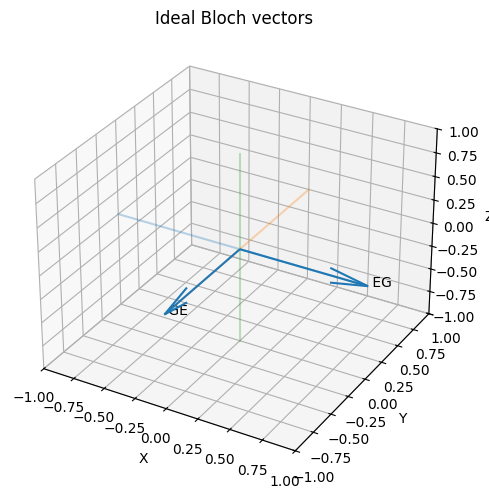

In [ ]:
ideal_counts_proxy = {}
for order in orders:
    vec = ideal_bloch[order]
    for basis, component in zip(["X", "Y", "Z"], vec):
        p0 = (component + 1) / 2
        n0 = int(round(p0 * SHOTS))
        n1 = SHOTS - n0
        ideal_counts_proxy[(order, basis)] = {"0": n0, "1": n1}

ideal_summary_df, ideal_bloch_from_counts, ideal_dist_counts, ideal_boot, _ = summarize_counts(
    ideal_counts_proxy, label="ideal_proxy"
)

display(ideal_summary_df)
print("Ideal Bloch vectors:", ideal_bloch)
print(f"Ideal Bloch distance = {ideal_distance:.6f}")
plot_bloch_vectors(ideal_bloch, "Ideal Bloch vectors");

## 6. Optional local sampled simulation

,source,ordering,basis,counts_0,counts_1,expectation,standard_error,shots
0,aer_noiseless,GE,X,2034,1966,0.0170,0.015809,4000
1,aer_noiseless,GE,Y,0,4000,-1.0000,0.000000,4000
2,aer_noiseless,GE,Z,1987,2013,-0.0065,0.015811,4000
3,aer_noiseless,EG,X,4000,0,1.0000,0.000000,4000
4,aer_noiseless,EG,Y,2057,1943,0.0285,0.015805,4000
5,aer_noiseless,EG,Z,2007,1993,0.0035,0.015811,4000


Aer Bloch vectors: {'GE': array([ 0.017 , -1.    , -0.0065]), 'EG': array([1.    , 0.0285, 0.0035])}
Aer Bloch distance = 0.711372
Bootstrap distance interval: {'mean': 0.7115348404926901, 'std': 0.00799888970353497, 'q025': 0.6959010997436982, 'q500': 0.7114224307632238, 'q975': 0.7273682032665191}


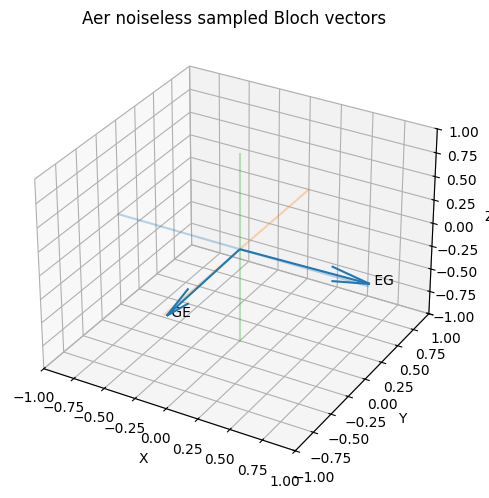

In [ ]:
sim_counts_by_order_basis = {}

if HAS_AER:
    simulator = AerSimulator()
    sim_circuits = [measure_circuits[(order, basis)] for order in orders for basis in bases]
    sim_result = simulator.run(sim_circuits, shots=SHOTS, seed_simulator=BOOTSTRAP_SEED).result()

    idx = 0
    for order in orders:
        for basis in bases:
            sim_counts_by_order_basis[(order, basis)] = normalize_counts(sim_result.get_counts(idx))
            idx += 1

    sim_summary_df, sim_bloch, sim_dist, sim_boot, _ = summarize_counts(sim_counts_by_order_basis, label="aer_noiseless")
    display(sim_summary_df)
    print("Aer Bloch vectors:", sim_bloch)
    print(f"Aer Bloch distance = {sim_dist:.6f}")
    print("Bootstrap distance interval:", sim_boot)
    plot_bloch_vectors(sim_bloch, "Aer noiseless sampled Bloch vectors");
else:
    print("Skipping Aer simulation because qiskit_aer is not installed.")

## 7. Submit to IBM hardware with Qiskit Runtime SamplerV2

Before running this section, ensure that your IBM Quantum account is configured.

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="YOUR TOKEN",
    overwrite=True,
    set_as_default=True
)

service = QiskitRuntimeService(channel="ibm_quantum_platform")
print(service.backends())

In [ ]:
def get_service():
    # Create a QiskitRuntimeService with fallback patterns.
    try:
        return QiskitRuntimeService()
    except Exception as exc1:
        print("QiskitRuntimeService() failed:", repr(exc1))

    try:
        return QiskitRuntimeService(channel="ibm_quantum_platform")
    except Exception as exc2:
        print('QiskitRuntimeService(channel="ibm_quantum_platform") failed:', repr(exc2))
        raise

def choose_backend(service, backend_name=None):
    if backend_name:
        return service.backend(backend_name)

    # Choose a least-busy operational hardware backend with at least one qubit.
    backends = service.backends(simulator=False, operational=True, min_num_qubits=1)
    if not backends:
        raise RuntimeError("No operational non-simulator backends available.")

    def pending_jobs(backend):
        try:
            return backend.status().pending_jobs
        except Exception:
            return 10**9

    return sorted(backends, key=pending_jobs)[0]

hardware_counts_by_order_basis = {}
hardware_metadata = {}

if RUN_HARDWARE:
    if not HAS_RUNTIME:
        raise RuntimeError("qiskit-ibm-runtime is not installed or failed to import.")

    service = get_service()
    backend = choose_backend(service, BACKEND_NAME)

    print("Using backend:", backend.name)

    hardware_circuits = [measure_circuits[(order, basis)] for order in orders for basis in bases]

    # Prefer the preset pass manager when available; fallback to transpile otherwise.
    try:
        from qiskit.transpiler import generate_preset_pass_manager
        pm = generate_preset_pass_manager(
            backend=backend,
            optimization_level=OPTIMIZATION_LEVEL,
        )
        transpiled_circuits = pm.run(hardware_circuits)
    except Exception as exc:
        print("generate_preset_pass_manager failed; falling back to transpile:", repr(exc))
        transpiled_circuits = transpile(
            hardware_circuits,
            backend=backend,
            optimization_level=OPTIMIZATION_LEVEL,
        )

    print("Transpiled circuit summary:")
    for circ in transpiled_circuits:
        print(circ.name, "depth:", circ.depth(), "ops:", dict(circ.count_ops()))

    sampler = Sampler(mode=backend)
    job = sampler.run(transpiled_circuits, shots=SHOTS)

    print("Submitted to:", backend.name)
    print("Job ID:", job.job_id())
    try:
        print("Initial status:", job.status())
    except Exception:
        pass

    result = job.result()
    print("Final status:", job.status())

    idx = 0
    for order in orders:
        for basis in bases:
            counts = extract_counts_from_sampler_result(result, idx)
            hardware_counts_by_order_basis[(order, basis)] = counts
            print(f"{order}_{basis} counts:", counts)
            idx += 1

    hardware_metadata = {
        "backend": backend.name,
        "job_id": job.job_id(),
        "shots": SHOTS,
        "optimization_level": OPTIMIZATION_LEVEL,
        "timestamp_utc": datetime.now(timezone.utc).isoformat(),
        "orders": orders,
        "bases": bases,
        "circuit_depths": {circ.name: circ.depth() for circ in transpiled_circuits},
        "circuit_ops": {circ.name: dict(circ.count_ops()) for circ in transpiled_circuits},
    }
else:
    print("RUN_HARDWARE is False. Set RUN_HARDWARE=True to submit to IBM hardware.")

qiskit_runtime_service.__init__:WARNING:2026-05-02 05:35:50,694: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-05-02 05:35:50,696: Using instance: open-instance, plan: open


Using backend: ibm_kingston
Transpiled circuit summary:
GE_X depth: 4 ops: {'rz': 2, 'sx': 1, 'barrier': 1, 'measure': 1}
GE_Y depth: 2 ops: {'x': 1, 'barrier': 1, 'measure': 1}
GE_Z depth: 3 ops: {'rz': 1, 'sx': 1, 'barrier': 1, 'measure': 1}
EG_X depth: 2 ops: {'rz': 1, 'barrier': 1, 'measure': 1}
EG_Y depth: 4 ops: {'rz': 2, 'sx': 1, 'barrier': 1, 'measure': 1}
EG_Z depth: 3 ops: {'sx': 1, 'rz': 1, 'barrier': 1, 'measure': 1}
Submitted to: ibm_kingston
Job ID: d7qoqect738s73ceo4k0
Initial status: QUEUED
Final status: DONE
GE_X counts: {'0': 2009, '1': 1991}
GE_Y counts: {'0': 60, '1': 3940}
GE_Z counts: {'0': 2038, '1': 1962}
EG_X counts: {'0': 3893, '1': 107}
EG_Y counts: {'0': 1975, '1': 2025}
EG_Z counts: {'0': 1961, '1': 2039}


## 8. Hardware analysis: Bloch vectors and ordering distance

,source,ordering,basis,counts_0,counts_1,expectation,standard_error,shots
0,hardware,GE,X,2009,1991,0.0045,0.015811,4000
1,hardware,GE,Y,60,3940,-0.9700,0.003844,4000
2,hardware,GE,Z,2038,1962,0.0190,0.015809,4000
3,hardware,EG,X,3893,107,0.9465,0.005102,4000
4,hardware,EG,Y,1975,2025,-0.0125,0.015810,4000
5,hardware,EG,Z,1961,2039,-0.0195,0.015808,4000


Hardware Bloch vectors:
GE [ 0.0045 -0.97    0.019 ]
EG [ 0.9465 -0.0125 -0.0195]
Hardware Bloch distance = 0.671873
Bootstrap distance summary: {'mean': 0.6720251408144222, 'std': 0.008285695891549958, 'q025': 0.6555193503997498, 'q500': 0.6718537554736426, 'q975': 0.6886452392064113}
Ideal Bloch distance = 0.707107


,ordering,ideal_rx,ideal_ry,ideal_rz,hardware_rx,hardware_ry,hardware_rz
0,GE,0.0,-1.000000e+00,2.220446e-16,0.0045,-0.9700,0.0190
1,EG,1.0,-2.220446e-16,2.220446e-16,0.9465,-0.0125,-0.0195


,source,bloch_distance,bootstrap_std,q025,q975
0,ideal,0.707107,NaN,NaN,NaN
1,hardware,0.671873,0.008286,0.655519,0.688645


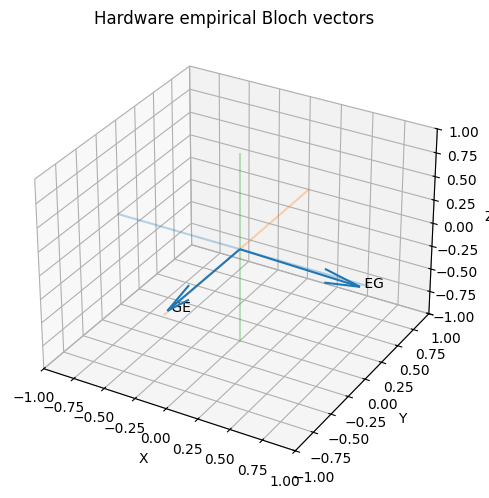

In [ ]:
if hardware_counts_by_order_basis:
    hardware_summary_df, hardware_bloch, hardware_dist, hardware_boot, hardware_components = summarize_counts(
        hardware_counts_by_order_basis,
        label="hardware",
    )

    display(hardware_summary_df)

    print("Hardware Bloch vectors:")
    for order, vec in hardware_bloch.items():
        print(order, vec)

    print(f"Hardware Bloch distance = {hardware_dist:.6f}")
    print("Bootstrap distance summary:", hardware_boot)
    print(f"Ideal Bloch distance = {ideal_distance:.6f}")

    plot_bloch_vectors(hardware_bloch, "Hardware empirical Bloch vectors");

    # Compare ideal and hardware in a compact table.
    comparison_rows = []
    for order in orders:
        comparison_rows.append({
            "ordering": order,
            "ideal_rx": ideal_bloch[order][0],
            "ideal_ry": ideal_bloch[order][1],
            "ideal_rz": ideal_bloch[order][2],
            "hardware_rx": hardware_bloch[order][0],
            "hardware_ry": hardware_bloch[order][1],
            "hardware_rz": hardware_bloch[order][2],
        })
    comparison_df = pd.DataFrame(comparison_rows)
    display(comparison_df)

    distance_df = pd.DataFrame([
        {
            "source": "ideal",
            "bloch_distance": ideal_distance,
            "bootstrap_std": np.nan,
            "q025": np.nan,
            "q975": np.nan,
        },
        {
            "source": "hardware",
            "bloch_distance": hardware_dist,
            "bootstrap_std": hardware_boot["std"],
            "q025": hardware_boot["q025"],
            "q975": hardware_boot["q975"],
        }
    ])
    display(distance_df)
else:
    print("No hardware counts available. Run the hardware submission cell first.")

## 9. Save auditable artifacts

In [ ]:
if hardware_counts_by_order_basis:
    run_id = f"{hardware_metadata.get('backend', 'backend')}_{hardware_metadata.get('job_id', 'job')}"
    safe_run_id = "".join(ch if ch.isalnum() or ch in "-_." else "_" for ch in run_id)

    counts_json = {
        f"{order}_{basis}": normalize_counts(counts)
        for (order, basis), counts in hardware_counts_by_order_basis.items()
    }

    output_payload = {
        "scope_note": (
            "Optional hardware execution sanity check. "
            "This is not a hardware estimate of the paper's channel-level C_G."
        ),
        "metadata": hardware_metadata,
        "ideal_bloch": {k: v.tolist() for k, v in ideal_bloch.items()},
        "ideal_bloch_distance": float(ideal_distance),
        "hardware_counts": counts_json,
        "hardware_bloch": {k: v.tolist() for k, v in hardware_bloch.items()},
        "hardware_bloch_distance": float(hardware_dist),
        "hardware_bloch_distance_bootstrap": hardware_boot,
    }

    json_path = OUTPUT_DIR / f"{safe_run_id}_hardware_ordering_probe.json"
    csv_path = OUTPUT_DIR / f"{safe_run_id}_hardware_ordering_probe_summary.csv"
    dist_csv_path = OUTPUT_DIR / f"{safe_run_id}_hardware_ordering_probe_distance.csv"

    with open(json_path, "w") as f:
        json.dump(output_payload, f, indent=2)

    hardware_summary_df.to_csv(csv_path, index=False)
    distance_df.to_csv(dist_csv_path, index=False)

    print("Saved:")
    print(json_path)
    print(csv_path)
    print(dist_csv_path)
else:
    print("No hardware results to save.")